# 3. Регрессионный анализ переменной CC50

**Цель**: построение регрессионной модели для предсказания значения CC50.

Параметр CC50 характеризует токсичность соединения, поэтому задача формулируется как задача регрессии.

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

# Загрузка подготовленных данных
df = pd.read_csv('cleaned_data.csv')

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (1001, 78)


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,NumRadicalElectrons,...,fr_para_hydroxylation,fr_phos_acid,fr_phos_ester,fr_prisulfonamd,fr_pyridine,fr_sulfide,fr_sulfone,fr_term_acetylene,fr_thiocyan,fr_urea
0,6.239374,175.482382,28.125000,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,0,...,0,0,0,0,0,0,0,0,0,0
1,0.771831,5.402819,7.000000,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,0,...,0,0,0,0,0,0,0,0,0,0
2,223.808778,161.142320,0.720000,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,0,...,0,0,0,0,0,0,0,0,0,0
3,1.705624,107.855654,63.235294,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,0,...,0,0,0,0,0,0,0,0,0,0
4,107.131532,139.270991,1.300000,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,0,...,0,0,0,0,0,0,0,0,0,0


## Подготовка данных

- В качестве целевой переменной используется логарифмированное значение CC50..

In [2]:
# Отделим целевые переменные
targets = ['IC50, mM', 'CC50, mM', 'SI']

# ЛОГАРИФМИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
y_raw = df['CC50, mM']
epsilon = 1e-9
y = np.log10(y_raw + epsilon)

X = df.drop(columns=targets, errors='ignore')

# Разделение на train и test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()
scaler.set_output(transform="pandas")

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Функция для безопасной очистки имён колонок (убираем запятые, пробелы и т.д.)
def clean_column_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]+', '_', str(col)) for col in df.columns]
    return df

# Очищаем имена колонок
X_train_scaled = clean_column_names(X_train_scaled)
X_test_scaled = clean_column_names(X_test_scaled)

print(f"Размерность X_train: {X_train_scaled.shape}")
print(f"Диапазон y_train (log10): [{y_train.min():.5f}, {y_train.max():.5f}]")


Размерность X_train: (800, 75)
Диапазон y_train (log10): [-0.15440, 3.65696]


## Обучение моделей

Для оценки качества решения были рассмотрены несколько моделей машинного обучения:

- линейные модели
- методы ближайших соседей
- ансамбли деревьев
- бустинговые методы

Сравнение моделей позволит определить, какой тип алгоритмов лучше подходит для задачи предсказания IC50.

In [3]:
# Словарь моделей
models = {
    "Ridge": Ridge(),
    "Lasso": Lasso(max_iter=1000),
    "KNN": KNeighborsRegressor(),
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(random_state=42, verbosity=0, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1, force_col_wise=True, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Метрики считаем на логарифмической шкале
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'RMSE_log': rmse, 'R^2_log': r2})

res_df = pd.DataFrame(results).sort_values(by='RMSE_log')
display(res_df)


,Model,RMSE_log,R^2_log
4,RandomForest,0.502286,0.436108
6,LightGBM,0.522607,0.389559
5,XGBoost,0.541004,0.345823
2,KNN,0.541081,0.345638
0,Ridge,0.578881,0.251015
3,LinearRegression,0.579289,0.249961
1,Lasso,0.672180,-0.009870


- По результатам сравнения видно, что наилучшее качество показывает RandomForest
- Линейные модели работают заметно хуже, делаем выводы об отсутствии выраженной линейной зависимости в данных.

## Подбор гиперпараметров

После первичного сравнения моделей выполняется подбор гиперпараметров для наиболее перспективной модели.

По 2м показателям RMSE и R2 `RandomForestRegressor` показывает лучший результат, поэтому для неё выполняется подбор гиперпараметров. Это позволяет дополнительно повысить качество предсказания и подобрать более оптимальную конфигурацию модели.

In [4]:
# Инициализируем модель
model = RandomForestRegressor(random_state=42, n_jobs=-1)

# Сетка параметров
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Настройка GridSearch
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# Запуск поиска
grid_search.fit(X_train_scaled, y_train)

# Вывод лучших параметров
print(f"\nЛучшие параметры RandomForest: {grid_search.best_params_}")
best_rf_model = grid_search.best_estimator_

# Оценка на тесте
y_pred_rf = best_rf_model.predict(X_test_scaled)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Оптимизированный RandomForest -> RMSE (в логарифмах): {rmse_rf:.4f}, R^2 (в логарифмах): {r2_rf:.4f}")



Fitting 3 folds for each of 81 candidates, totalling 243 fits

Лучшие параметры RandomForest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Оптимизированный RandomForest -> RMSE (в логарифмах): 0.4988, R^2 (в логарифмах): 0.4440


## Визуализация

Для более детального анализа качества модели рассмотрим визуализации предсказаний и ошибок модели.

Это позволит понять:
- насколько хорошо модель предсказывает реальные значения
- есть ли систематические ошибки
- на каких объектах модель работает хуже

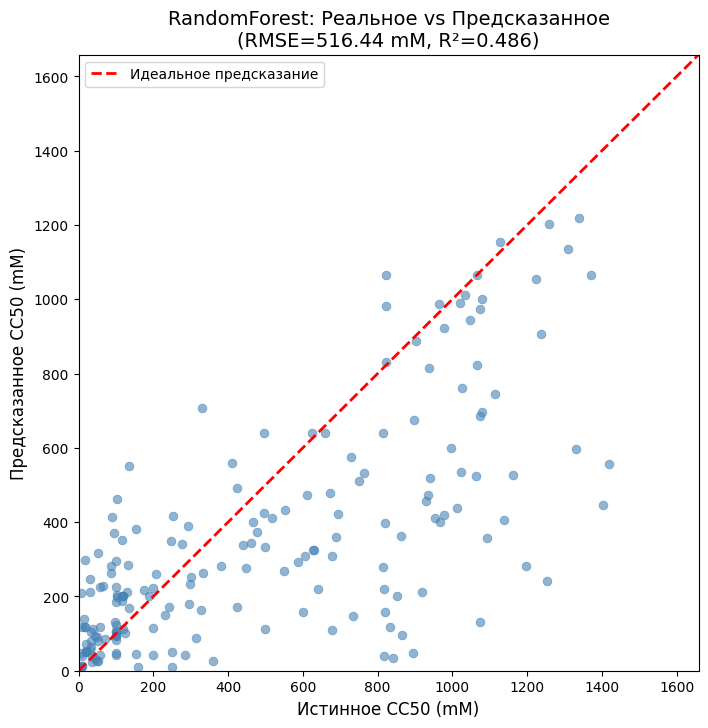

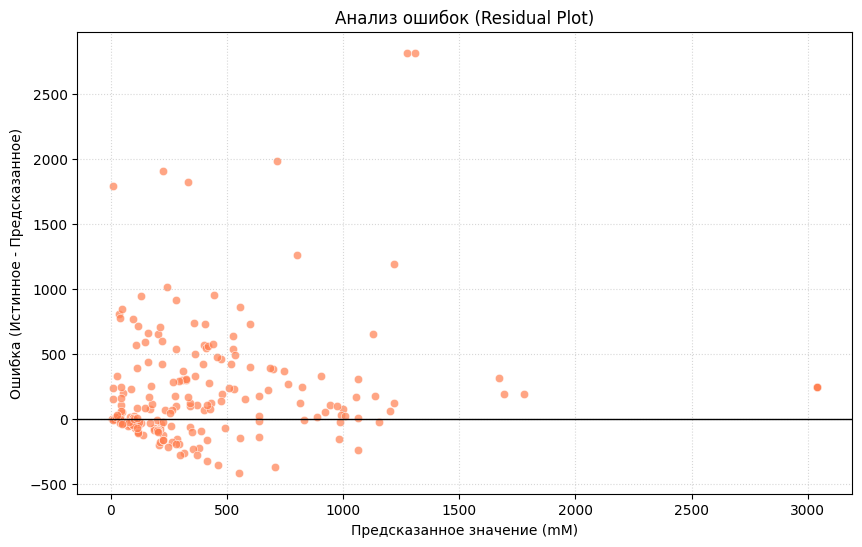

Средняя абсолютная ошибка (MAE) в mM: 296.4884 mM
Максимальная ошибка в mM: 2820.3100 mM


In [5]:
# Используем модель (best_rf_model) и данные (X_test_scaled)
y_pred_log = best_rf_model.predict(X_test_scaled)

# Обратное преобразование: 10^x
epsilon = 1e-9
y_test_real = (10 ** y_test) - epsilon
y_pred_real = (10 ** y_pred_log) - epsilon

# Защита от отрицательных значений из-за округления (если вдруг)
y_test_real = np.maximum(y_test_real, 0)
y_pred_real = np.maximum(y_pred_real, 0)

# Ограничиваем график 95-м перцентилем, чтобы выбросы не растягивали оси
limit = np.percentile(np.concatenate([y_test_real, y_pred_real]), 95)

#plt.style.use('seaborn-v0_8-whitegrid')

# ГРАФИК 1: Scatter Plot (Реальное vs Предсказанное)
plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test_real,
    y=y_pred_real,
    alpha=0.6,
    s=40,
    edgecolor=None,
    color='steelblue'
)

# Линия идеального совпадения
plt.plot([0, limit], [0, limit], color='red', linestyle='--', linewidth=2, label='Идеальное предсказание')

plt.xlim(0, limit)
plt.ylim(0, limit)

plt.xlabel("Истинное CC50 (mM)", fontsize=12)
plt.ylabel("Предсказанное CC50 (mM)", fontsize=12)
plt.title(f"RandomForest: Реальное vs Предсказанное\n(RMSE={np.sqrt(mean_squared_error(y_test_real, y_pred_real)):.2f} mM, R²={r2_score(y_test_real, y_pred_real):.3f})", fontsize=14)
plt.legend()
plt.show()

# ГРАФИК 2: Residuals (Ошибки модели)
# Это покажет, есть ли систематическая ошибка (например, модель всегда завышает низкие значения)
residuals = y_test_real - y_pred_real

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_real, y=residuals, alpha=0.7, color='coral')
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.xlabel("Предсказанное значение (mM)")
plt.ylabel("Ошибка (Истинное - Предсказанное)")
plt.title("Анализ ошибок (Residual Plot)")
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()

# Вывод статистики ошибок
print(f"Средняя абсолютная ошибка (MAE) в mM: {np.mean(np.abs(residuals)):.4f} mM")
print(f"Максимальная ошибка в mM: {np.max(np.abs(residuals)):.4f} mM")



- **Качество модели умеренное.** Метрики: RMSE составляет 516.55 mM, а коэффициент детерминации R^2 = 0.485. Значение коэффициента детерминации говорит о том, что модель объясняет чуть менее половины дисперсии данных (48.5%).
- **Визуальный анализ:** Точки в целом следуют за линией идеального предсказания, что указывает на наличие общей линейной тенденции. Однако наблюдается значительный разброс точек, особенно в средней части диапазона (400–1000 mM), что подтверждает наличие систематических ошибок.
- модель может занижать предсказания для самых высоких значений. Точки ниже илеального предсказания

Построим бар-чарт, чтобы наглядно увидеть разрыв между линейными и ансамблевыми методами:

/tmp/ipykernel_346/727442704.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df.sort_values('RMSE_log'), x='RMSE_log', y='Model', palette='viridis')


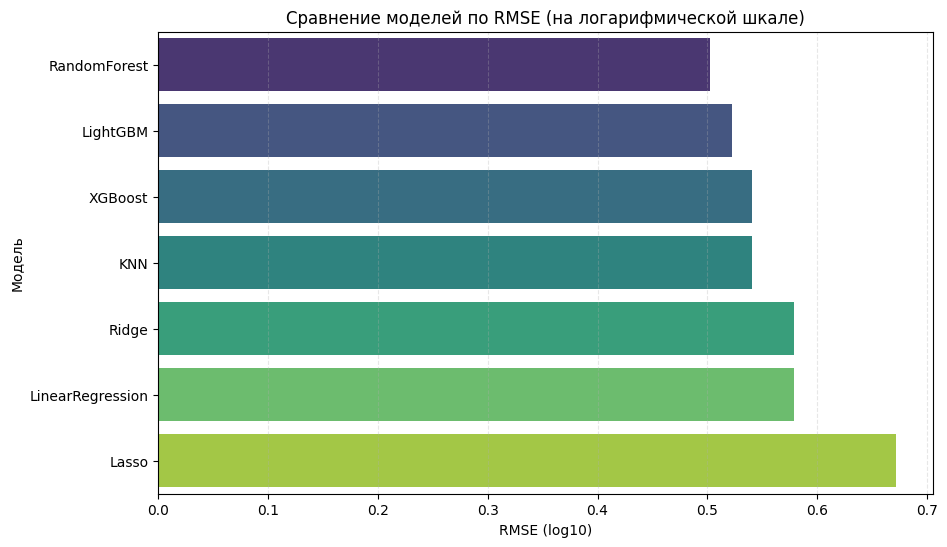

In [6]:
plt.figure(figsize=(10, 6))
# Сортируем: RMSE по возрастанию
sns.barplot(data=res_df.sort_values('RMSE_log'), x='RMSE_log', y='Model', palette='viridis')
plt.title('Сравнение моделей по RMSE (на логарифмической шкале)')
plt.xlabel('RMSE (log10)')
plt.ylabel('Модель')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show();

- По результатам сравнительного анализа наилучшее качество предсказания CC50 продемонстрировал алгоритм RandomForest, показав минимальное значение метрики RMSE на логарифмической шкале.
- Ансамблевые методы (LightGBM, XGBoost) также заняли лидирующие позиции.
- Линейные модели (Lasso, Ridge, LinearRegression) существенно отстают по точности.

## Выводы по моделированию CC50

- Мы построили модель, чтобы предсказывать CC50.
- Проверили разные алгоритмы: линейные (Ridge, Lasso) и ансамблевые (случайный лес, бустинг).
- Линейные модели работали хуже - в данных нет простой прямой связи между признаками и результатом.
- Лучше всего справился RandomForest: он умеет ловить сложные зависимости и не так сильно реагирует на выбросы.

В итоге для этой задачи лучше использовать ансамблевые методы.